# 📊 Exploración de Fuentes y Análisis de Casuística de Fallos (Capa Bronze)

## 1. Introducción y Objetivos
Este Notebook está destinado al **Análisis Exploratorio de Datos (EDA)** del parque eólico Kelmarsh. El objetivo principal es auditar la calidad de los datos en la capa **Bronze** antes de consolidar las transformaciones de producción hacia la capa **Silver**.

Específicamente nos centraremos en:
1. **Inspección Estructural:** Documentar el esquema y consistencia de los logs de estado (`Status`).
2. **Análisis de Casuística de Fallos:** Clasificar y limpiar los más de 38000 eventos para determinar cuáles representan paradas críticas reales y cuáles son alertas operativas o paradas programadas.
3. **Optimización del Target (PdM):** Evaluar la ventana de degradación temporal óptima para el etiquetado del modelo predictivo de IA.

---

## 2. Inicialización del Entorno Spark
Configuramos una sesión local optimizada explotando la paralelización del hardware disponible.

In [2]:
import os
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

# ==============================================================================
# 1. CONFIGURACIÓN E INICIALIZACIÓN DEL ENTORNO SPARK LOCAL
# ==============================================================================
# Inicializar Spark optimizado para el hardware local (6 cores en paralelo)
spark = SparkSession.builder \
    .appName("Kelmarsh-EDA-Notebook") \
    .master("local[6]") \
    .config("spark.driver.memory", "8g") \
    .getOrCreate()

# ==============================================================================
# 2. INGESTA EXCLUSIVA DE RUTAS INTERESADAS (VENTANA ESTRICTA 2021-2024)
# ==============================================================================
# Definir rutas base desde la carpeta de ejecución de notebooks
base_dir = os.path.dirname(os.getcwd())
bronze_dir = os.path.join(base_dir, "data", "bronze")

# Mapear explícitamente solo los directorios de los años requeridos
# De esta forma, ignoramos por completo cualquier carpeta del 2017 al 2020
target_years = ["2021", "2022", "2023", "2024"]
selected_paths = []

for year in target_years:
    # Construimos la ruta exacta hacia los archivos de la Turbina 1 de cada año
    year_pattern = os.path.join(bronze_dir, f"Kelmarsh_SCADA_{year}_*", f"Status_Kelmarsh_1_*.csv")
    selected_paths.append(year_pattern)

# Cargar ÚNICAMENTE los archivos que cumplen con la selección estricta
status_df = spark.read \
    .option("header", "True") \
    .option("inferSchema", "True") \
    .option("comment", "#") \
    .csv(selected_paths)

# ==============================================================================
# 3. INSPECCIÓN DE ESQUEMA Y MUESTRA DE DATOS
# ==============================================================================
print("📋 ESTRUCTURA DE COLUMNAS DETECTADA (SCHEMA):")
status_df.printSchema()

print("VISTA PREVIA DE LAS PRIMERAS 5 FILAS (ESTRICTO 2021-2024):")
status_df.show(5, truncate=False)

# ==============================================================================
# 4. AUDITORÍA DE VOLUMETRÍA EN BRUTO DE LA VENTANA SELECCIONADA
# ==============================================================================
# Calcular las métricas de volumen reales cargadas en memoria
total_records = status_df.count()

print(f"🎯 Total de registros leídos para el entrenamiento (2021-2024): {total_records}")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/05/29 21:26:12 WARN Utils: Your hostname, medion, resolves to a loopback address: 127.0.1.1; using 192.168.1.113 instead (on interface wlo1)
26/05/29 21:26:12 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/29 21:26:13 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


📋 ESTRUCTURA DE COLUMNAS DETECTADA (SCHEMA):
root
 |-- Timestamp start: timestamp (nullable = true)
 |-- Timestamp end: string (nullable = true)
 |-- Duration: string (nullable = true)
 |-- Status: string (nullable = true)
 |-- Code: integer (nullable = true)
 |-- Message: string (nullable = true)
 |-- Comment: string (nullable = true)
 |-- Service contract category: string (nullable = true)
 |-- IEC category: string (nullable = true)
 |-- Global contract category: string (nullable = true)
 |-- Custom contract category: string (nullable = true)

VISTA PREVIA DE LAS PRIMERAS 5 FILAS (ESTRICTO 2021-2024):
+-------------------+-------------------+--------+-------------+------+---------------------+-------+-------------------------+-----------------+-------------------------+------------------------+
|Timestamp start    |Timestamp end      |Duration|Status       |Code  |Message              |Comment|Service contract category|IEC category     |Global contract category |Custom contract categ

---

## 3. Introducción al Análisis de Códigos y Mensajes del SCADA

Antes de agrupar y filtrar a ciegas, necesitamos entender qué está registrando realmente el sistema de control de la turbina. El objetivo de esta sección es extraer la lista completa de códigos únicos presentes en la capa Bronze.

Analizaremos la combinación de:
* El mensaje de error (`Message`).
* La categoría contractual (`Service contract category`).
* La norma internacional de energía eólica (`IEC category`).

Esto nos permitirá concluir con datos reales qué eventos son averías críticas y cuáles son simples paradas operacionales o caídas de comunicación.

In [3]:
# ==============================================================================
# EXPLORACIÓN INICIAL: VOLUMETRÍA GENERAL DE EVENTOS EN BRUTO
# ==============================================================================
# Agrupar de forma estricta por código y mensaje para consolidar el catálogo único
# Se extrae el primer valor detectado de las categorías para evitar duplicados por strings
raw_catalog_df = status_df.groupBy("Code", "Message") \
    .agg(
        F.first("Status").alias("Status"),
        F.first("Service contract category").alias("Service contract category"),
        F.first("IEC category").alias("IEC category"),
        F.count("*").alias("Occurrence_Count")
    ) \
    .orderBy(F.desc("Occurrence_Count"))

# Calcular dinámicamente el número total de códigos únicos reales en la ventana
total_raw_codes = raw_catalog_df.count()

print(f"📊 EL CATÁLOGO EN BRUTO TIENE UN TOTAL DE: {total_raw_codes} CÓDIGOS ÚNICOS\n")
print("🎯 MOSTRANDO LOS EVENTOS MÁS FRECUENTES EN EL PARQUE:")

# Mostrar el Top 40 de casuísticas en la consola de Spark sin truncar textos
raw_catalog_df.show(truncate=False)

# Sumar el total de frecuencias acumuladas en el catálogo consolidado
total_catalog_sum = raw_catalog_df.agg(F.sum("Occurrence_Count")).collect()[0][0]

# Validar mediante un condicional booleano si el cuadre es perfecto al 100%
if total_catalog_sum == total_records:
    print("\n✅ ¡VERIFICACIÓN EXITOSA! La suma total de 'Occurrence_Count' cuadra con el numero de eventos inicial. Cero pérdidas de información en Spark.\n")
else:
    print("\n⚠️ ¡ATENCIÓN! Existe una discrepancia entre la carga inicial y la agrupación. Revisar nulos en claves.\n")

📊 EL CATÁLOGO EN BRUTO TIENE UN TOTAL DE: 105 CÓDIGOS ÚNICOS

🎯 MOSTRANDO LOS EVENTOS MÁS FRECUENTES EN EL PARQUE:
+------+-----------------------------+-------------+-----------------------------------+----------------------------------+----------------+
|Code  |Message                      |Status       |Service contract category          |IEC category                      |Occurrence_Count|
+------+-----------------------------+-------------+-----------------------------------+----------------------------------+----------------+
|100130|Automatic start-up           |Informational|NULL                               |Full Performance                  |4812            |
|100180|Run-up                       |Informational|NULL                               |Technical Standby                 |4646            |
|100190|Mains connection             |Informational|NULL                               |Full Performance                  |4234            |
|100200|Mains run-up                 |I

Para evitar pérdidas de información, nuestro análisis no se limita a la frecuencia. Un evento crítico con baja frecuencia (incluso Occurrence_Count = 1) puede ser el precursor de una avería grave o un fallo sistémico.

In [4]:
# Obtener los Status únicos presentes en el dataset
unique_statuses = status_df.select("Status").distinct().rdd.flatMap(lambda x: x).collect()

print("📋 LISTADO DE STATUS ÚNICOS ENCONTRADOS:")
print(unique_statuses)

📋 LISTADO DE STATUS ÚNICOS ENCONTRADOS:
['Stop', 'Informational', 'Curtailment', 'Communication', 'Warning']


Para filtrar el catalogo de fallos, utilizaremos los estados 'Stop', 'Warning' y 'Communication'. El objetivo es identificar y aislar los códigos específicos que actúan como precursores de fallos. Al separar estos eventos de la operativa normal ('Informational' y 'Curtailment'), podremos etiquetar con precisión las causas raíz que preceden a una parada definitiva, permitiendo que la IA se entrene exclusivamente sobre el catálogo de señales críticas de anomalía.

---

## 4. Aislamiento de Todos los Eventos Críticos (Stops, Warnings y Communication)

En esta sección, filtramos el dataset completo para extraer de forma hermética todos los códigos catalogados como Stop, Warning o Communication. Este prefiltro actúa como una red de seguridad técnica que aísla las señales de anomalía y el comportamiento errático de los activos, permitiendo identificar los códigos raíz que preceden a una parada definitiva antes de pasar al entrenamiento de la IA.

In [5]:
# ==============================================================================
# PREFILTRO DE EVENTOS CRÍTICOS Y EXTRACCIÓN DE CÓDIGOS DE FALLO
# ==============================================================================

# Aplicamos prefiltro: Stop, Warning y Communication como indicadores de anomalía
critical_events_df = status_df.filter(
    F.col("Status").isin(["Stop", "Warning", "Communication"])
)

# Consolidamos el catálogo de códigos críticos detectados
critical_codes_catalog = critical_events_df.groupBy("Code", "Message") \
    .agg(
        F.first("Status").alias("Status"),
        F.count("*").alias("Failure_Frequency")
    ) \
    .orderBy(F.desc("Failure_Frequency"))

# Imprimimos resultados del prefiltro
print(f"📊 EL CATÁLOGO DE FALLOS TIENE UN TOTAL DE: {critical_codes_catalog.count()} CÓDIGOS ÚNICOS\n")
print("🎯 CÓDIGOS IDENTIFICADOS EN EL PREFILTRO DE EVENTOS CRÍTICOS:")
critical_codes_catalog.show(truncate=False)




📊 EL CATÁLOGO DE FALLOS TIENE UN TOTAL DE: 66 CÓDIGOS ÚNICOS

🎯 CÓDIGOS IDENTIFICADOS EN EL PREFILTRO DE EVENTOS CRÍTICOS:
+----+--------------------------------+-------------+-----------------+
|Code|Message                         |Status       |Failure_Frequency|
+----+--------------------------------+-------------+-----------------+
|710 |Battery test                    |Stop         |200              |
|6525|4-20mA anemometer 2             |Warning      |174              |
|6635|4-20 mA vane 2                  |Warning      |174              |
|6052|High yaw motor current          |Warning      |157              |
|6530|Anemometer defect               |Stop         |75               |
|6200|Cable autounwind                |Stop         |59               |
|20  |Manual stop - on site           |Stop         |57               |
|9997|Data communication unavailable  |Communication|44               |
|2125|Timeout brake closed            |Warning      |41               |
|5760|Hydraul

La lista de 66 códigos posee el tamaño idóneo para ser exportada a un archivo físico local `.txt`. Este archivo funcionará como nuestra "herramienta de control de calidad", permitiendo auditar el catálogo completo sin truncados y extraer el criterio empírico necesario para diseñar las siguientes capas de filtrado inteligente.

In [6]:
# ==============================================================================
# EXPORTACIÓN A TXT: GUARDADO DEL CATÁLOGO DE FALLOS
# ==============================================================================

# Definimos la ruta del archivo
initial_audit_file_path = "initial_catalog_audit.txt"

# Convertimos a formato Pandas para asegurar que la exportación sea un archivo legible y ordenado
# (Si tu dataset es muy grande, esta opción es segura al tener ya agrupados los 66 códigos)
pd_catalog = critical_codes_catalog.toPandas()

# Exportamos a un archivo de texto plano con formato de tabla
with open(initial_audit_file_path, "w", encoding="utf-8") as f:
    f.write("CATÁLOGO DE CÓDIGOS CRÍTICOS IDENTIFICADOS (PREFILTRO)\n")
    f.write("=" * 60 + "\n\n")
    f.write(pd_catalog.to_string(index=False))

print(f"✅ ¡ÉXITO! Catálogo exportado correctamente en: {initial_audit_file_path}")

✅ ¡ÉXITO! Catálogo exportado correctamente en: initial_catalog_audit.txt


---

## 5. Conclusión de la Auditoría Visual preliminar (66 Eventos)

La inspección lineal de los 66 códigos extraídos en el archivo `initial_catalog_audit.txt` ha sido determinante para detectar de forma quirúrgica el ruido operativo restante. Al tratarse de un volumen tan acotado y manejable, se ha descartado el uso de expresiones regulares complejas para evitar el riesgo de falsos positivos léxicos. En su lugar, la auditoría visual nos ha proporcionado el mapa exacto de los códigos de infraestructura, caídas de red externa (distribuidora) e intervenciones humanas directas. Este análisis empírico justifica la inyección directa de estos IDs específicos en la lista definitiva de exclusión, garantizando una purga 100% segura y permitiendo aislar de forma exacta las 37 averías de funcionamiento puras que entrenarán el modelo de IA.

In [ ]:
# ==============================================================================
# FILTRADO CRÍTICO DEFINITIVO: EXCLUSIÓN DE CÓDIGOS DE RUIDO POR ID
# ==============================================================================

# Lista maestra de IDs excluidos tras la inspección visual (Infraestructura, red y humanos)
operational_and_external_ids = [
    # --- Paradas manuales y rutinas operacionales ---
    20,    # Parada manual en campo
    21,    # Parada manual remota
    25,    # Parada manual sin inicio de sesión
    210,   # Freno manual
    707,   # Fin del test de baterías (rutina programada)
    710,   # Test de baterías (rutina programada)
    720,   # Ciclo de carga de baterías de pitch (rutina)
    5760,  # Operación de purga de aceite hidráulico (mantenimiento)
    6200,  # Desenrollado automático de cables (operacional)
    8000,  # Parada maestra del parque (comando supervisor externo)

    # --- Red eléctrica exterior (no predecible) ---
    3500,  # Pérdida de red (Grid loss)
    3000,  # Convertidor de frecuencia no listo (revisar: excluir si siempre va precedido de grid loss o parada manual)

    # --- Factores climáticos y condiciones ambientales externas ---
    61,    # Viento inferior a potencia mínima
    68,    # Desviación de dirección de viento > 60°
    6540,  # Hielo detectado en anemómetro
    6682,  # Hielo detectado (desviación de potencia eléctrica)
    6690,  # Parada por hielo

    # --- Equipos auxiliares no críticos para producción ---
    5000,  # Avería en luz de obstáculos (no afecta operación del aerogenerador)

    # --- Comunicación, sincronización e infraestructura TI ---
    9997,  # Comunicación de datos no disponible
    8400,  # Fallo de comunicación FPM
    7325,  # Fallo en sincronización horaria (SNTP)
    7324,  # Comprobar sincronización horaria
    3125,  # Tiempo de espera agotado para conexión

    # --- Errores repetitivos de bus de campo (posible ruido, no fallo físico) ---
    440,   # Error repetitivo BP 0
    455,   # Error repetitivo BP52

    # --- Cadena de seguridad (requiere revisión manual, no predecible por IA) ---
    100,   # Cadena de seguridad abierta
]

# ==============================================================================
# APLICACIÓN DEL FILTRADO INTEGRAL EN LA CAPA SILVER
# ==============================================================================
catalogo_fallos_reales_df = status_df.filter(
    # 1. Mantener solo eventos críticos que detienen o avisan de anomalías
    (F.col("Status").isin("Warning", "Stop")) &
    
    # 2. Hachazo directo a los códigos identificados en la auditoría visual
    (~F.col("Code").isin(operational_and_external_ids))
)

# Cacheamos el DataFrame en memoria por eficiencia técnica para los siguientes cálculos
catalogo_fallos_reales_df.cache()

# ==============================================================================
# AUDITORÍA Y VERIFICACIÓN DE VOLUMETRÍA FINAL (SIN DUPLICADOS)
# ==============================================================================

# 1. Agrupamos para obtener los conteos, pero manteniendo los datos necesarios
catalogo_agrupado = catalogo_fallos_reales_df.groupBy(
    "Code", "Message", "Status", "Service contract category", "IEC category"
).count()

# 2. Eliminamos duplicados basándonos ÚNICAMENTE en el código.
# Si un código tiene varias versiones (por mensaje, etc.), nos quedamos con la primera 
# que encuentre o la que tenga mayor conteo si ordenamos antes.
catalogo_final = catalogo_agrupado.orderBy(F.desc("count")).dropDuplicates(["Code"]).orderBy("Code")

# Calcular el nuevo número de códigos únicos
final_failures_count = catalogo_final.count()

print(f"🎯 EL CATÁLOGO DEFINITIVO TIENE EXACTAMENTE: {final_failures_count} CÓDIGOS ÚNICOS.")
print("📋 VISTA GLOBAL DEL CATÁLOGO PURGADO (BASE DEL TARGET):")

# Forzar a show a mostrar el total exacto (37) para evitar cortes (...)
catalogo_final.show(n=final_failures_count + 5, truncate=False)

# ==============================================================================
# EXPORTACIÓN DEL REPORTE DE AUDITORÍA FÍSICO (.TXT)
# ==============================================================================
# Definir la ruta del archivo final en el espacio de trabajo
final_audit_file_path = "failure_catalog_audit.txt"

# Recolectar las 37 filas limpias en local para la escritura secuencial
final_catalog_rows = catalogo_final.collect()

# Abrir el archivo en modo escritura para guardar el catálogo definitivo limpio
with open(final_audit_file_path, "w", encoding="utf-8") as file:
    file.write(f"📋 CATALOGO TOTAL DE AVERIAS DE FUNCIONAMIENTO COMPLETO ({final_failures_count} EVENTOS)\n")
    file.write("=" * 100 + "\n")
    file.write(f"{'CÓDIGO':<8} | {'MENSAJE':<40} | {'STATUS':<8} | {'CATEGORÍA CONTRACTUAL'}\n")
    file.write("-" * 100 + "\n")
    
    for row in final_catalog_rows:
        file.write(f"{str(row['Code']):<8} | {str(row['Message']):<40} | {str(row['Status']):<8} | {str(row['Service contract category'])}\n")

print(f"✅ ¡Archivo '{final_audit_file_path}' generado on éxito!")


26/05/29 21:39:22 WARN CacheManager: Asked to cache already cached data.


🎯 EL CATÁLOGO DEFINITIVO TIENE EXACTAMENTE: 40 CÓDIGOS ÚNICOS.
📋 VISTA GLOBAL DEL CATÁLOGO PURGADO (BASE DEL TARGET):
+----+----------------------------------------+-------+-----------------------------------+-------------------------------+-----+
|Code|Message                                 |Status |Service contract category          |IEC category                   |count|
+----+----------------------------------------+-------+-----------------------------------+-------------------------------+-----+
|59  |Max. acceleration                       |Warning|Operating states  (28)             |Full Performance               |5    |
|675 |Pitch measuring system 1><2             |Warning|Warnings (27)                      |Full Performance               |14   |
|681 |Limit switch error 95° axis 1           |Warning|Warnings (27)                      |Forced outage                  |2    |
|682 |Limit switch error 95° axis 2           |Warning|Warnings (27)                      |Forced outa

In [14]:
# 1. Creamos la lógica de ventanas según el tipo de fallo
# Puedes usar un 'when' para asignar horas según la categoría o el código
catalogo_final = catalogo_final.withColumn(
    "Degradation_Window_Hours",
    F.when(F.col("Code").isin([5720, 2674]), 24)    # Fallos mecánicos/térmicos: Ventana de 24h
     .when(F.col("Code").isin([100, 440]), 2)       # Fallos eléctricos rápidos: Ventana de 2h
     .otherwise(168)                                # Por defecto: 1 semana (168 horas) para desgaste
)

# 2. Ahora exportamos con esa nueva columna
catalog_df_pd = catalogo_final.toPandas()
catalog_df_pd.to_csv('../data/silver/technical_fault_catalog.csv', index=False)

print("✅ Catálogo exportado con columnas de ventana de degradación incluidas.")

✅ Catálogo exportado con columnas de ventana de degradación incluidas.


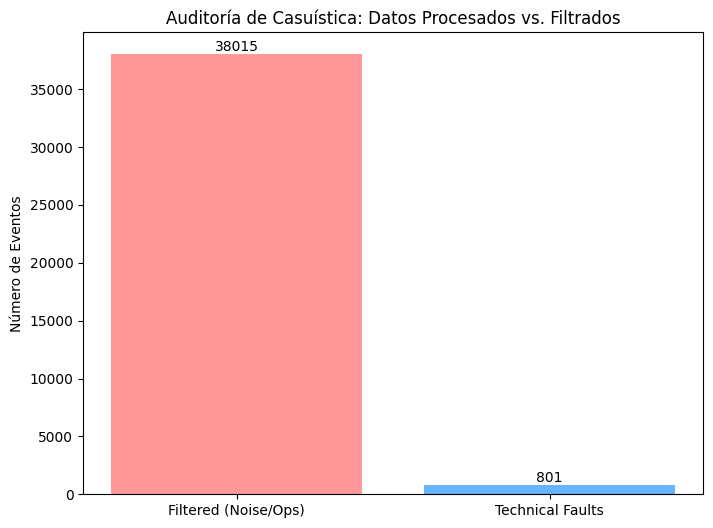

In [13]:
import matplotlib.pyplot as plt

# 1. Obtenemos el total de eventos originales y los que han pasado el filtro
total_raw = status_df.count()
final_kept = catalogo_final.select(F.sum("count")).collect()[0][0]
discarded = total_raw - final_kept

# 2. Preparamos los datos para el gráfico de auditoría
data = {'Status': ['Filtered (Noise/Ops)', 'Technical Faults'],
        'Count': [discarded, final_kept]}
df_audit = pd.DataFrame(data)

# 3. Dibujamos la auditoría
plt.figure(figsize=(8, 6))
plt.bar(df_audit['Status'], df_audit['Count'], color=['#ff9999','#66b3ff'])
plt.title('Auditoría de Casuística: Datos Procesados vs. Filtrados')
plt.ylabel('Número de Eventos')
plt.text(0, discarded, str(discarded), ha='center', va='bottom')
plt.text(1, final_kept, str(final_kept), ha='center', va='bottom')
plt.show()

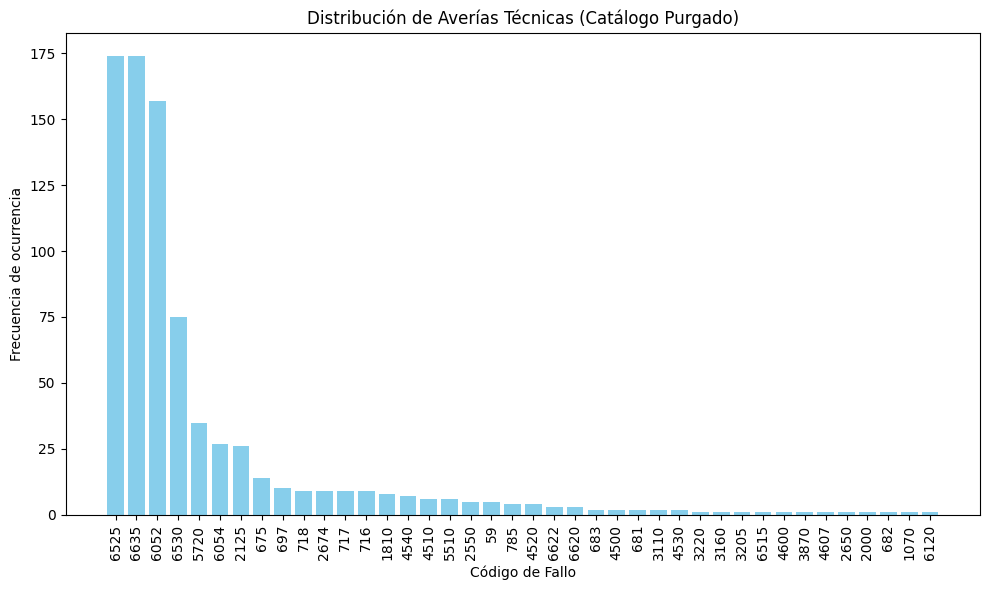

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

# Convertimos a Pandas solo para graficar (es pequeño)
df_plot = catalogo_final.toPandas() 
# Aquí podrías calcular también el total de descartados vs. mantenidos usando el dataframe original
# para mostrar la "reducción de ruido"

plt.figure(figsize=(10, 6))
plt.bar(df_plot['Code'].astype(str), df_plot['count'], color='skyblue')
plt.title('Distribución de Averías Técnicas (Catálogo Purgado)')
plt.xlabel('Código de Fallo')
plt.ylabel('Frecuencia de ocurrencia')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()